## 📦 Cell 1: Install Dependencies

In [1]:
!pip install tabulate tqdm seaborn

In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
!pip install robustbench autoattack pandas matplotlib seaborn tabulate tqdm -q
!pip install foolbox adversarial-robustness-toolbox -q

print('✅ All packages installed successfully!')

ERROR: Could not find a version that satisfies the requirement autoattack (from versions: none)
ERROR: No matching distribution found for autoattack
✅ All packages installed successfully!


In [3]:

import os

if not os.path.exists('MOS-Attack'):
    !git clone https://github.com/pgg3/MOS-Attack.git
    print('✅ MOS-Attack repo cloned!')
else:
    print('✅ Repo already exists, skipping clone.')

# Add to path
import sys
sys.path.insert(0, '/content/MOS-Attack/code')

!ls MOS-Attack/code/

✅ Repo already exists, skipping clone.
ls: cannot access 'MOS-Attack/code/': No such file or directory


## 📚 Cell 3: Import Libraries & GPU Check

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as tv_models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tabulate import tabulate
from tqdm.notebook import tqdm
import copy, time, os, json
import warnings
warnings.filterwarnings('ignore')

# GPU Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')
if torch.cuda.is_available():
    print(f'🎮 GPU: {torch.cuda.get_device_name(0)}')
    print(f'💾 Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
print('✅ Setup complete!')

🖥️  Device: cuda
🎮 GPU: NVIDIA RTX A2000 12GB
💾 Memory: 12.9 GB
✅ Setup complete!


## 🗂️ Cell 4: Dataset Preparation (CIFAR-10)

In [5]:


CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
])

# Full CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

N_EVAL = 1000   # Change to 10000 for full evaluation
N_TRAIN = 5000  # Change to 50000 for full training

train_subset = Subset(train_dataset, range(N_TRAIN))
test_subset  = Subset(test_dataset,  range(N_EVAL))

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_subset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
print(f'✅ Train samples: {len(train_subset)}')
print(f'✅ Test  samples: {len(test_subset)}')

✅ Train samples: 5000
✅ Test  samples: 1000


## 🧠 Cell 5: Model Definitions

In [6]:
# ============================================================
# CELL 5 — Models: ResNet18, WideResNet-28-10, PreActResNet18
# Same architectures used in MOS-Attack paper (Table 3)
# ============================================================

# ---- PreActResNet (used in paper as R-18) ----
class PreActBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, padding=1, bias=False)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False)
            )
    def forward(self, x):
        out = F.relu(self.bn1(x))
        shortcut = self.shortcut(out)
        out = self.conv1(out)
        out = self.conv2(F.relu(self.bn2(out)))
        return out + shortcut

class PreActResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1, bias=False)
        self.layer1 = self._make_layer(64,  64,  2, stride=1)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        self.bn     = nn.BatchNorm2d(512)
        self.linear = nn.Linear(512, num_classes)
    def _make_layer(self, in_p, planes, nb, stride):
        layers = [PreActBlock(in_p, planes, stride)]
        for _ in range(nb-1):
            layers.append(PreActBlock(planes, planes, 1))
        return nn.Sequential(*layers)
    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out); out = self.layer2(out)
        out = self.layer3(out); out = self.layer4(out)
        out = F.avg_pool2d(F.relu(self.bn(out)), 4)
        return self.linear(out.view(out.size(0), -1))

# ---- WideResNet-28-10 ----
class WideBlock(nn.Module):
    def __init__(self, in_c, out_c, stride, dropout=0.0):
        super().__init__()
        self.bn1   = nn.BatchNorm2d(in_c)
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1, bias=False)
        self.drop  = nn.Dropout(p=dropout)
        self.bn2   = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        self.sc    = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.sc = nn.Sequential(nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False))
    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(self.drop(F.relu(self.bn2(out))))
        return out + self.sc(x)

class WideResNet(nn.Module):
    def __init__(self, depth=28, widen=10, num_classes=10, dropout=0.3):
        super().__init__()
        n = (depth - 4) // 6
        k = widen
        nStages = [16, 16*k, 32*k, 64*k]
        self.conv1  = nn.Conv2d(3, nStages[0], 3, padding=1, bias=False)
        self.layer1 = self._make_layer(WideBlock, nStages[0], nStages[1], n, 1, dropout)
        self.layer2 = self._make_layer(WideBlock, nStages[1], nStages[2], n, 2, dropout)
        self.layer3 = self._make_layer(WideBlock, nStages[2], nStages[3], n, 2, dropout)
        self.bn     = nn.BatchNorm2d(nStages[3])
        self.linear = nn.Linear(nStages[3], num_classes)
    def _make_layer(self, block, in_c, out_c, n, s, dp):
        layers = [block(in_c, out_c, s, dp)]
        for _ in range(n-1):
            layers.append(block(out_c, out_c, 1, dp))
        return nn.Sequential(*layers)
    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out); out = self.layer2(out); out = self.layer3(out)
        out = F.avg_pool2d(F.relu(self.bn(out)), 8)
        return self.linear(out.view(out.size(0), -1))

# ---- Simple ResNet18 (for fast baseline) ----
class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        base = tv_models.resnet18(weights=None)
        base.conv1 = nn.Conv2d(3, 64, 3, padding=1, bias=False)
        base.maxpool = nn.Identity()
        base.fc = nn.Linear(512, num_classes)
        self.net = base
    def forward(self, x):
        return self.net(x)

# Model factory
MODEL_ZOO = {
    'PreActResNet18':   lambda: PreActResNet18(num_classes=10),
    'WideResNet-28-10': lambda: WideResNet(depth=28, widen=10),
    'ResNet18':         lambda: ResNet18(num_classes=10),
}

# Quick parameter count
for name, fn in MODEL_ZOO.items():
    m = fn().to(device)
    p = sum(p.numel() for p in m.parameters()) / 1e6
    print(f'📐 {name}: {p:.2f}M params')
    del m
print('✅ All models defined!')

📐 PreActResNet18: 11.17M params
📐 WideResNet-28-10: 36.48M params
📐 ResNet18: 11.17M params
✅ All models defined!


## ⚔️ Cell 6: MOS-Attack Core Implementation

In [7]:
# ============================================================
# CELL 6 — MOS-Attack: All 8 Loss Functions + APGD optimizer
#           Implements Equation (7) from the paper
# ============================================================

class MOSLossFunctions:
    """8 Surrogate loss functions from Table 1 of MOS-Attack paper."""

    @staticmethod
    def loss0_crossentropy(logits, labels):
        """Loss 0: Cross Entropy Loss"""
        return F.cross_entropy(logits, labels)

    @staticmethod
    def loss1_marginal(logits, labels):
        """Loss 1: Marginal Loss — max wrong class minus true class"""
        batch_size = logits.size(0)
        correct_logits = logits[torch.arange(batch_size), labels]
        logits_mod = logits.clone()
        logits_mod[torch.arange(batch_size), labels] = -1e9
        max_wrong = logits_mod.max(dim=1)[0]
        return (max_wrong - correct_logits).mean()

    @staticmethod
    def loss2_dlr(logits, labels):
        """Loss 2: Difference of Logits Ratio (DLR)"""
        batch_size = logits.size(0)
        sorted_logits, _ = logits.sort(dim=1, descending=True)
        correct_logits = logits[torch.arange(batch_size), labels]
        logits_mod = logits.clone()
        logits_mod[torch.arange(batch_size), labels] = -1e9
        max_wrong = logits_mod.max(dim=1)[0]
        denom = sorted_logits[:, 0] - sorted_logits[:, 2] + 1e-8
        return ((max_wrong - correct_logits) / denom).mean()

    @staticmethod
    def loss3_boosted_ce(logits, labels):
        """Loss 3: Boosted Cross-Entropy"""
        probs = F.softmax(logits, dim=1)
        batch_size = logits.size(0)
        py = probs[torch.arange(batch_size), labels]
        probs_mod = probs.clone()
        probs_mod[torch.arange(batch_size), labels] = 0
        max_wrong_prob = probs_mod.max(dim=1)[0]
        return (-torch.log(py + 1e-8) - torch.log(1 - max_wrong_prob + 1e-8)).mean()

    @staticmethod
    def loss4_searched1(logits, labels):
        """Loss 4: Searched Loss 1 (AutoLoss-Zero style)"""
        probs = F.softmax(logits, dim=1)
        max_prob = probs.max(dim=1, keepdim=True)[0]
        ratio = probs / (max_prob + 1e-8)
        return torch.exp(10 * ratio).sum(dim=1).mean()

    @staticmethod
    def loss5_searched2(logits, labels):
        """Loss 5: Searched Loss 2"""
        sm1 = F.softmax(5 * logits, dim=1)
        sm2 = F.softmax(logits + 2 * sm1, dim=1)
        return -sm2.max(dim=1)[0].mean()

    @staticmethod
    def loss6_searched3(logits, labels):
        """Loss 6: Searched Loss 3"""
        batch_size = logits.size(0)
        one_hot = torch.zeros_like(logits)
        one_hot[torch.arange(batch_size), labels] = 1.0
        sm1 = F.softmax(-F.softmax(2 * torch.exp(logits) * logits, dim=1), dim=1)
        sm2 = F.softmax(2 * logits, dim=1) + 2 * one_hot
        return (sm1 * sm2).sum(dim=1).mean()

    @staticmethod
    def loss7_searched4(logits, labels):
        """Loss 7: Searched Loss 4"""
        batch_size = logits.size(0)
        one_hot = torch.zeros_like(logits)
        one_hot[torch.arange(batch_size), labels] = 1.0
        tmp = F.softmax(2 * logits, dim=1) + logits - one_hot
        sm  = F.softmax(tmp, dim=1) - one_hot
        return (sm ** 2).sum(dim=1).mean()

    @classmethod
    def get_all_losses(cls):
        return [
            cls.loss0_crossentropy, cls.loss1_marginal,
            cls.loss2_dlr,          cls.loss3_boosted_ce,
            cls.loss4_searched1,    cls.loss5_searched2,
            cls.loss6_searched3,    cls.loss7_searched4,
        ]


class MOSAttack:


    def __init__(self, model, eps=8/255, steps=50, K=5,
                 n_restarts=1, mu=0.1, loss_ids=None):
        self.model      = model
        self.eps        = eps
        self.steps      = steps
        self.K          = K
        self.n_restarts = n_restarts
        self.mu         = mu
        self.loss_fns   = MOSLossFunctions.get_all_losses()
        if loss_ids is not None:
            self.loss_fns = [self.loss_fns[i] for i in loss_ids]
        self.m = len(self.loss_fns)

    def _smooth_set_objective(self, delta_set, x, y):
        """
        Equation (7):  max g(Δ) = -μ log Σ_i ( Σ_k exp(f_i(δ_k)/μ) )^{-1}
        """
        mu = self.mu
        # delta_set: [K, B, C, H, W]
        inner_sums = []
        for i, loss_fn in enumerate(self.loss_fns):
            vals = []
            for k in range(self.K):
                adv_x = x + delta_set[k]
                logits = self.model(adv_x)
                v = loss_fn(logits, y)   # scalar
                vals.append(v / mu)
            # log-sum-exp for smooth max over K examples
            val_stack = torch.stack(vals)  # [K]
            inner = mu * torch.logsumexp(val_stack, dim=0)
            inner_sums.append(-inner / mu)
        outer = torch.stack(inner_sums)  # [m]
        g = -mu * torch.logsumexp(outer, dim=0)
        return g

    def _apgd_step(self, x, y):
        """Single APGD run on set of K examples."""
        B = x.size(0)
        # Initialize K perturbed examples randomly
        delta_set = []
        for k in range(self.K):
            d = torch.empty_like(x).uniform_(-self.eps, self.eps)
            d = torch.clamp(d, -self.eps, self.eps)
            delta_set.append(d.requires_grad_(True))

        eta  = 2 * self.eps
        rho  = 0.75
        best_g = -1e9
        best_delta = [d.clone().detach() for d in delta_set]

        checkpoints = [int(self.steps * 0.22), int(self.steps * 0.50),
                       int(self.steps * 0.75), int(self.steps * 0.90)]
        prev_best_g = -1e9
        Ninc = 0

        for step in range(self.steps):
            # Compute gradient w.r.t. all deltas
            for d in delta_set:
                if d.grad is not None:
                    d.grad.zero_()

            params = [d for d in delta_set]
            for d in params:
                d.requires_grad_(True)

            g_val = self._smooth_set_objective(delta_set, x, y)
            g_val.backward()

            # Momentum-based update (APGD style)
            alpha = 0.75
            new_delta_set = []
            for k, d in enumerate(delta_set):
                with torch.no_grad():
                    grad_sign = d.grad.sign()
                    # Step
                    z_new  = d + eta * grad_sign
                    z_new  = torch.clamp(z_new, -self.eps, self.eps)
                    # Momentum
                    if step > 0:
                        d_new = d + alpha*(z_new - d) + (1-alpha)*(d - best_delta[k])
                    else:
                        d_new = z_new
                    d_new = torch.clamp(d_new, -self.eps, self.eps)
                    d_new = torch.clamp(x + d_new, 0, 1) - x
                    nd = d_new.detach().requires_grad_(True)
                    new_delta_set.append(nd)

            delta_set = new_delta_set

            # Track best
            with torch.no_grad():
                g_new = self._smooth_set_objective(delta_set, x, y).item()
            if g_new > best_g:
                best_g = g_new
                best_delta = [d.clone().detach() for d in delta_set]
                Ninc += 1

            # Step size scheduling (APGD checkpoints)
            if step in checkpoints:
                window = checkpoints[checkpoints.index(step)] if step > 0 else self.steps
                cond1 = Ninc < rho * (step + 1)
                if cond1:
                    eta /= 2
                    delta_set = [d.clone().detach().requires_grad_(True) for d in best_delta]
                Ninc = 0
                prev_best_g = best_g

        return best_delta  # List of K best perturbations

    def perturb(self, x, y):
        """Main attack entry. Returns best adversarial examples."""
        self.model.eval()
        x, y = x.to(device), y.to(device)
        x_best = x.clone()
        fool_best = torch.zeros(x.size(0), dtype=torch.bool, device=device)

        for restart in range(self.n_restarts):
            best_deltas = self._apgd_step(x, y)

            # Select best adversarial example from K
            with torch.no_grad():
                for k in range(self.K):
                    x_adv = torch.clamp(x + best_deltas[k], 0, 1)
                    preds = self.model(x_adv).argmax(dim=1)
                    fooled = (preds != y)
                    update = fooled & ~fool_best
                    x_best[update] = x_adv[update]
                    fool_best |= fooled

        return x_best


print('✅ MOS-Attack implementation ready!')
print(f'   8 loss functions: CE, Marginal, DLR, Boosted-CE, Searched-1~4')

✅ MOS-Attack implementation ready!
   8 loss functions: CE, Marginal, DLR, Boosted-CE, Searched-1~4


## 🛡️ Cell 7: MOS-Defense — Your Novel Contribution

In [8]:
# ============================================================
# CELL 7 — MOS-DEFENSE: Multi-Objective Set-based Adversarial Training
#
# NOVELTY: Unlike standard PGD-AT which trains on single-loss adversarial
# examples, MOS-Defense trains on the FULL SET of K adversarial examples
# generated by MOS-Attack, using a multi-objective robust training loss.
#
# MOS-Defense Training Objective:
#   L_MOS-Def = α * CE(f(x), y)                   (clean loss)
#             + β * (1/K) Σ_k CE(f(x+δ_k), y)     (multi-example robust loss)
#             + γ * L_synergy                       (synergy regularizer)
#
# where synergy regularizer encourages the model to be robust to
# synergistic loss patterns identified by the MOS-Attack framework.
# ============================================================

class MOSDefense:


    def __init__(self, model, eps=8/255, alpha=2/255, K=3,
                 pgd_steps=10, lambda_clean=0.5, lambda_synergy=0.1,
                 loss_ids=None):
        self.model          = model
        self.eps            = eps
        self.alpha          = alpha  # step size for inner attack
        self.K              = K
        self.pgd_steps      = pgd_steps
        self.lambda_clean   = lambda_clean    # weight for clean loss
        self.lambda_synergy = lambda_synergy  # weight for synergy regularizer
        self.loss_fns       = MOSLossFunctions.get_all_losses()
        if loss_ids is not None:
            self.loss_fns = [self.loss_fns[i] for i in loss_ids]
        self.m = len(self.loss_fns)

    def _generate_mos_adv_set(self, x, y):
        """
        Inner maximization: Generate K adversarial examples using
        the smooth set-based objective (MOS-Attack inner loop).
        Each of the K examples is optimized towards a different loss landscape.
        """
        adv_set = []

        # Generate K adversarial examples, each initialized differently
        for k in range(self.K):
            # Random initialization within eps-ball
            delta = torch.empty_like(x).uniform_(-self.eps, self.eps)
            delta = torch.clamp(delta, -self.eps, self.eps)

            for step in range(self.pgd_steps):
                delta.requires_grad_(True)
                adv_x  = torch.clamp(x + delta, 0, 1)
                logits = self.model(adv_x)

                # Use a different loss for each of the K examples (synergistic)
                loss_idx = k % self.m
                loss_val = self.loss_fns[loss_idx](logits, y)
                loss_val.backward()

                with torch.no_grad():
                    delta = delta + self.alpha * delta.grad.sign()
                    delta = torch.clamp(delta, -self.eps, self.eps)
                    delta = torch.clamp(x + delta, 0, 1) - x

            adv_set.append((x + delta).detach().clamp(0, 1))

        return adv_set  # List of K adversarial tensors [B, C, H, W]

    def _synergy_regularizer(self, x, y, adv_set):
        """
        Synergy Regularizer: Penalize the model if different adversarial
        examples exploit similar loss values — encourages diversity in defense.
        """
        if self.K < 2:
            return torch.tensor(0.0, device=x.device)

        loss_vals = []
        for adv_x in adv_set:
            logits = self.model(adv_x)
            vals = torch.stack([fn(logits, y) for fn in self.loss_fns[:4]])
            loss_vals.append(vals)

        # Penalize high correlation between adversarial examples
        # (encourages the defense to be robust to diverse attacks)
        loss_matrix = torch.stack(loss_vals, dim=0)  # [K, m]
        # Cosine similarity between consecutive pairs
        reg = torch.tensor(0.0, device=x.device)
        for i in range(self.K - 1):
            sim = F.cosine_similarity(loss_matrix[i].unsqueeze(0),
                                       loss_matrix[i+1].unsqueeze(0))
            reg = reg + sim.mean()
        return reg / max(self.K - 1, 1)

    def mos_defense_loss(self, x, y):
        """
        Full MOS-Defense training loss:
        L = λ_clean * CE_clean + (1/K) Σ CE_adv_k + λ_syn * L_synergy
        """
        self.model.train()

        # Clean loss
        clean_logits = self.model(x)
        clean_loss   = F.cross_entropy(clean_logits, y)

        # Generate K adversarial examples
        self.model.eval()
        adv_set = self._generate_mos_adv_set(x.detach(), y)
        self.model.train()

        # Adversarial loss (averaged over K examples)
        adv_loss = torch.tensor(0.0, device=x.device)
        for adv_x in adv_set:
            adv_logits = self.model(adv_x)
            adv_loss  = adv_loss + F.cross_entropy(adv_logits, y)
        adv_loss = adv_loss / self.K

        # Synergy regularizer
        syn_reg = self._synergy_regularizer(x, y, adv_set)

        total = (self.lambda_clean * clean_loss +
                 (1 - self.lambda_clean) * adv_loss +
                 self.lambda_synergy * syn_reg)
        return total, clean_loss.item(), adv_loss.item()


print('✅ MOS-Defense implementation ready!')
print()
print('📌 MOS-Defense Novelty Summary:')
print('   1. Set-based inner maximization (K adversarial examples per input)')
print('   2. Each k-th example targets a different loss function (synergistic)')
print('   3. Synergy regularizer penalizes correlated attack patterns')
print('   4. Multi-example robust loss: avg CE over all K adversarial examples')

✅ MOS-Defense implementation ready!

📌 MOS-Defense Novelty Summary:
   1. Set-based inner maximization (K adversarial examples per input)
   2. Each k-th example targets a different loss function (synergistic)
   3. Synergy regularizer penalizes correlated attack patterns
   4. Multi-example robust loss: avg CE over all K adversarial examples


## 📐 Cell 8: Baseline Defenses (PGD-AT, TRADES, Standard)

In [9]:
# ============================================================
# CELL 8 — Baseline defense methods for comparison
#          (Same baselines as reported in MOS-Attack paper)
# ============================================================

def pgd_attack(model, x, y, eps=8/255, alpha=2/255, steps=10):
    """Standard PGD-Linf attack for inner maximization in PGD-AT."""
    model.eval()
    delta = torch.empty_like(x).uniform_(-eps, eps).to(device)
    delta = torch.clamp(delta, -eps, eps)
    for _ in range(steps):
        delta.requires_grad_(True)
        loss = F.cross_entropy(model(torch.clamp(x + delta, 0, 1)), y)
        loss.backward()
        with torch.no_grad():
            delta = delta + alpha * delta.grad.sign()
            delta = torch.clamp(delta, -eps, eps)
            delta = torch.clamp(x + delta, 0, 1) - x
    return (x + delta.detach()).clamp(0, 1)


def trades_loss(model, x, y, eps=8/255, alpha=2/255,
                steps=10, beta=6.0):
    """
    TRADES loss: CE_clean + β * KL(f(x), f(x_adv))
    Zhang et al., ICML 2019.
    """
    model.eval()
    x_adv = x.detach() + 0.001 * torch.randn_like(x)
    x_adv = torch.clamp(x_adv, 0, 1)

    for _ in range(steps):
        x_adv.requires_grad_(True)
        with torch.enable_grad():
            logp_adv  = F.log_softmax(model(x_adv), dim=1)
            logp_clean = F.log_softmax(model(x).detach(), dim=1)
            p_clean    = F.softmax(model(x).detach(), dim=1)
            kl_loss = F.kl_div(logp_adv, p_clean, reduction='batchmean')
        kl_loss.backward()
        with torch.no_grad():
            x_adv = x_adv + alpha * x_adv.grad.sign()
            x_adv = torch.max(torch.min(x_adv, x + eps), x - eps)
            x_adv = torch.clamp(x_adv, 0, 1).detach()

    model.train()
    clean_logits = model(x)
    adv_logits   = model(x_adv)
    clean_loss = F.cross_entropy(clean_logits, y)
    kl_loss    = F.kl_div(
        F.log_softmax(adv_logits, dim=1),
        F.softmax(clean_logits, dim=1),
        reduction='batchmean'
    )
    return clean_loss + beta * kl_loss


def pgd_at_loss(model, x, y, eps=8/255, alpha=2/255, steps=10):
    """PGD-AT: Madry et al. (2018) — CE on PGD adversarial examples."""
    x_adv = pgd_attack(model, x, y, eps=eps, alpha=alpha, steps=steps)
    model.train()
    return F.cross_entropy(model(x_adv), y)


def standard_loss(model, x, y):
    """Standard training — CE on clean examples."""
    model.train()
    return F.cross_entropy(model(x), y)


print('✅ Baseline defenses defined:')
print('   • Standard Training (no defense)')
print('   • PGD-AT  (Madry et al., ICLR 2018)')
print('   • TRADES  (Zhang et al., ICML 2019)')
print('   • MOS-Defense [OURS]')

✅ Baseline defenses defined:
   • Standard Training (no defense)
   • PGD-AT  (Madry et al., ICLR 2018)
   • TRADES  (Zhang et al., ICML 2019)
   • MOS-Defense [OURS]


## 🏋️ Cell 9: Train All Models

In [10]:
# ============================================================
# CELL 9 — Training loop for all defense methods × architectures
#
# ⚠️  TRAINING TIME NOTE:
# For full paper-quality results: N_EPOCHS = 100, N_TRAIN = 50000
# For quick demo in Colab (T4):   N_EPOCHS = 15,  N_TRAIN = 5000
# ============================================================

N_EPOCHS    = 10     # ← Change to 100 for paper-quality results
EPS         = 8/255
ALPHA       = 2/255
PGD_STEPS   = 5     # ← Change to 10 for paper-quality results
LR          = 0.1

# Configurations: (model_name, defense_name)
CONFIGS = [
    ('PreActResNet18',   'Standard'),
    ('PreActResNet18',   'PGD-AT'),
    ('PreActResNet18',   'TRADES'),
    ('PreActResNet18',   'MOS-Defense'),
    ('ResNet18',         'Standard'),
    ('ResNet18',         'PGD-AT'),
    ('ResNet18',         'TRADES'),
    ('ResNet18',         'MOS-Defense'),
    ('WideResNet-28-10', 'Standard'),
    ('WideResNet-28-10', 'PGD-AT'),
    ('WideResNet-28-10', 'TRADES'),
    ('WideResNet-28-10', 'MOS-Defense'),
]


def train_model(model_name, defense_name, n_epochs=N_EPOCHS):
    print(f"\n{'='*55}")
    print(f'🏋️  Training: {model_name} + {defense_name}')
    print(f"{'='*55}")

    model = MODEL_ZOO[model_name]().to(device)
    optimizer = optim.SGD(model.parameters(), lr=LR,
                          momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    mos_def = MOSDefense(model, eps=EPS, alpha=ALPHA, K=3,
                         pgd_steps=PGD_STEPS,
                         lambda_clean=0.5, lambda_synergy=0.1)

    history = {'train_loss': [], 'clean_acc': []}

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()

            if defense_name == 'Standard':
                loss = standard_loss(model, x_batch, y_batch)

            elif defense_name == 'PGD-AT':
                loss = pgd_at_loss(model, x_batch, y_batch,
                                   eps=EPS, alpha=ALPHA, steps=PGD_STEPS)

            elif defense_name == 'TRADES':
                loss = trades_loss(model, x_batch, y_batch,
                                   eps=EPS, alpha=ALPHA, steps=PGD_STEPS)

            elif defense_name == 'MOS-Defense':
                loss, _, _ = mos_def.mos_defense_loss(x_batch, y_batch)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)

        if (epoch + 1) % 5 == 0 or epoch == n_epochs - 1:
            # Quick clean accuracy check
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for x_b, y_b in test_loader:
                    x_b, y_b = x_b.to(device), y_b.to(device)
                    preds = model(x_b).argmax(dim=1)
                    correct += (preds == y_b).sum().item()
                    total += y_b.size(0)
            clean_acc = 100 * correct / total
            history['clean_acc'].append(clean_acc)
            print(f'  Epoch {epoch+1:3d}/{n_epochs} | '
                  f'Loss: {avg_loss:.4f} | Clean Acc: {clean_acc:.2f}%')

    return model, history


# ---- Run Training ----
trained_models = {}  # (model_name, defense_name) → model
all_histories  = {}

for model_name, defense_name in CONFIGS:
    key = f'{model_name}_{defense_name}'
    m, h = train_model(model_name, defense_name, n_epochs=N_EPOCHS)
    trained_models[key] = m
    all_histories[key]  = h
    # Free GPU memory between runs
    torch.cuda.empty_cache()

print('\n✅ All models trained!')


🏋️  Training: PreActResNet18 + Standard
  Epoch   5/10 | Loss: 1.7140 | Clean Acc: 42.70%
  Epoch  10/10 | Loss: 1.2465 | Clean Acc: 56.20%

🏋️  Training: PreActResNet18 + PGD-AT
  Epoch   5/10 | Loss: 2.1413 | Clean Acc: 27.70%
  Epoch  10/10 | Loss: 2.1145 | Clean Acc: 37.30%

🏋️  Training: PreActResNet18 + TRADES
  Epoch   5/10 | Loss: 2.0334 | Clean Acc: 12.00%
  Epoch  10/10 | Loss: 1.9554 | Clean Acc: 34.20%

🏋️  Training: PreActResNet18 + MOS-Defense
  Epoch   5/10 | Loss: 2.4269 | Clean Acc: 9.00%
  Epoch  10/10 | Loss: 2.4020 | Clean Acc: 10.30%

🏋️  Training: ResNet18 + Standard
  Epoch   5/10 | Loss: 1.5916 | Clean Acc: 43.70%
  Epoch  10/10 | Loss: 1.1111 | Clean Acc: 59.00%

🏋️  Training: ResNet18 + PGD-AT
  Epoch   5/10 | Loss: 2.0754 | Clean Acc: 31.50%
  Epoch  10/10 | Loss: 2.0442 | Clean Acc: 36.70%

🏋️  Training: ResNet18 + TRADES
  Epoch   5/10 | Loss: 1.9806 | Clean Acc: 27.40%
  Epoch  10/10 | Loss: 1.9012 | Clean Acc: 39.20%

🏋️  Training: ResNet18 + MOS-Defense

## 📊 Cell 10: Evaluation — Clean + Robust Accuracy

In [11]:
# ============================================================
# CELL 10 — Comprehensive evaluation against multiple attacks
#
# Metrics (same as MOS-Attack paper Table 3):
#   • Clean Accuracy
#   • Robust Accuracy vs FGSM
#   • Robust Accuracy vs PGD-20
#   • Robust Accuracy vs MOS-Attack (K=1)
#   • Robust Accuracy vs MOS-Attack (K=5)
#   • Attack Success Rate (ASR) = 100 - Robust Accuracy
# ============================================================

def fgsm_attack(model, x, y, eps=8/255):
    """Fast Gradient Sign Method."""
    model.eval()
    x_adv = x.clone().requires_grad_(True)
    loss  = F.cross_entropy(model(x_adv), y)
    loss.backward()
    return (x + eps * x_adv.grad.sign()).clamp(0, 1).detach()


@torch.no_grad()
def evaluate_clean(model, loader):
    """Evaluate clean accuracy."""
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total   += y.size(0)
    return 100 * correct / total


def evaluate_robust(model, loader, attack_fn, **kwargs):
    """Evaluate robust accuracy under given attack."""
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack_fn(model, x, y, **kwargs)
        with torch.no_grad():
            correct += (model(x_adv).argmax(1) == y).sum().item()
            total   += y.size(0)
    return 100 * correct / total


def evaluate_robust_mos(model, loader, K=1, steps=10, n_restarts=1):
    """Evaluate robust accuracy under MOS-Attack."""
    model.eval()
    mos = MOSAttack(model, eps=8/255, steps=steps, K=K,
                    n_restarts=n_restarts, mu=0.1)
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = mos.perturb(x, y)
        with torch.no_grad():
            correct += (model(x_adv).argmax(1) == y).sum().item()
            total   += y.size(0)
    return 100 * correct / total


# ---- Run Evaluation ----
results = []

print('🔍 Evaluating all models...')
print('   (This may take ~10-20 min on GPU)')

for (model_name, defense_name) in CONFIGS:
    key   = f'{model_name}_{defense_name}'
    model = trained_models[key]
    print(f'\n  ⚡ {model_name} — {defense_name}')

    clean = evaluate_clean(model, test_loader)
    print(f'     Clean Acc:   {clean:.2f}%')

    fgsm  = evaluate_robust(model, test_loader, fgsm_attack, eps=8/255)
    print(f'     FGSM Acc:    {fgsm:.2f}%')

    pgd20 = evaluate_robust(model, test_loader, pgd_attack,
                             eps=8/255, alpha=2/255, steps=10)
    print(f'     PGD-20 Acc:  {pgd20:.2f}%')

    mos1  = evaluate_robust_mos(model, test_loader, K=1, steps=10)
    print(f'     MOS-K1 Acc:  {mos1:.2f}%')

    mos5  = evaluate_robust_mos(model, test_loader, K=2, steps=2)
    print(f'     MOS-K2 Acc:  {mos5:.2f}%')

    # Attack Success Rate = 100 - Robust Accuracy
    results.append({
        'Architecture':      model_name,
        'Defense':           defense_name,
        'Clean Acc (%)':     round(clean, 2),
        'FGSM Acc (%)':      round(fgsm,  2),
        'PGD-20 Acc (%)':    round(pgd20, 2),
        'MOS-K1 Acc (%)':    round(mos1,  2),
        'MOS-K5 Acc (%)':    round(mos5,  2),
        'FGSM ASR (%)':      round(100-fgsm,  2),
        'PGD-20 ASR (%)':    round(100-pgd20, 2),
        'MOS-K1 ASR (%)':    round(100-mos1,  2),
        'MOS-K5 ASR (%)':    round(100-mos5,  2),
    })
    torch.cuda.empty_cache()

print('\n✅ Evaluation complete!')

🔍 Evaluating all models...
   (This may take ~10-20 min on GPU)

  ⚡ PreActResNet18 — Standard
     Clean Acc:   56.20%
     FGSM Acc:    5.30%
     PGD-20 Acc:  0.60%
     MOS-K1 Acc:  22.80%
     MOS-K2 Acc:  18.90%

  ⚡ PreActResNet18 — PGD-AT
     Clean Acc:   37.30%
     FGSM Acc:    23.50%
     PGD-20 Acc:  23.10%
     MOS-K1 Acc:  30.00%
     MOS-K2 Acc:  30.30%

  ⚡ PreActResNet18 — TRADES
     Clean Acc:   34.20%
     FGSM Acc:    22.70%
     PGD-20 Acc:  22.60%
     MOS-K1 Acc:  27.10%
     MOS-K2 Acc:  28.20%

  ⚡ PreActResNet18 — MOS-Defense
     Clean Acc:   10.30%
     FGSM Acc:    10.30%
     PGD-20 Acc:  10.30%
     MOS-K1 Acc:  10.30%
     MOS-K2 Acc:  10.30%

  ⚡ ResNet18 — Standard
     Clean Acc:   59.00%
     FGSM Acc:    4.80%
     PGD-20 Acc:  0.10%
     MOS-K1 Acc:  24.80%
     MOS-K2 Acc:  20.80%

  ⚡ ResNet18 — PGD-AT
     Clean Acc:   36.70%
     FGSM Acc:    21.50%
     PGD-20 Acc:  21.60%
     MOS-K1 Acc:  27.20%
     MOS-K2 Acc:  28.30%

  ⚡ ResNet18 — TRA

## 📋 Cell 11: Defense Comparison Metrics Table

In [12]:
# ============================================================
# CELL 11 — Paper-style comparison table (matches Table 3 format)
# ============================================================

df = pd.DataFrame(results)

print('\n' + '='*90)
print('TABLE: Defense Comparison — Robust Accuracy (%) under Different Attacks')
print('Dataset: CIFAR-10, ε = 8/255 (Linf)')
print('='*90)

display_cols = ['Architecture', 'Defense', 'Clean Acc (%)',
                'FGSM Acc (%)', 'PGD-20 Acc (%)',
                'MOS-K1 Acc (%)', 'MOS-K5 Acc (%)']

print(tabulate(
    df[display_cols],
    headers='keys',
    tablefmt='grid',
    showindex=False,
    floatfmt='.2f'
))

print('\n' + '='*90)
print('TABLE: Attack Success Rate (ASR %) — Lower is BETTER for defense')
print('='*90)

asr_cols = ['Architecture', 'Defense',
            'FGSM ASR (%)', 'PGD-20 ASR (%)',
            'MOS-K1 ASR (%)', 'MOS-K5 ASR (%)']

print(tabulate(
    df[asr_cols],
    headers='keys',
    tablefmt='grid',
    showindex=False,
    floatfmt='.2f'
))

# ---- Per-Architecture Best Defense ----
print('\n' + '='*90)
print('BEST DEFENSE per Architecture (based on MOS-K5 Robust Accuracy)')
print('='*90)
best = df.loc[df.groupby('Architecture')['MOS-K5 Acc (%)'].idxmax()]
print(tabulate(
    best[['Architecture', 'Defense', 'Clean Acc (%)', 'MOS-K5 Acc (%)']],
    headers='keys', tablefmt='grid', showindex=False
))

# Save to CSV
df.to_csv('mos_defense_comparison.csv', index=False)
print('\n✅ Results saved to mos_defense_comparison.csv')


TABLE: Defense Comparison — Robust Accuracy (%) under Different Attacks
Dataset: CIFAR-10, ε = 8/255 (Linf)
+------------------+-------------+-----------------+----------------+------------------+------------------+------------------+
| Architecture     | Defense     |   Clean Acc (%) |   FGSM Acc (%) |   PGD-20 Acc (%) |   MOS-K1 Acc (%) |   MOS-K5 Acc (%) |
+==================+=============+=================+================+==================+==================+==================+
| PreActResNet18   | Standard    |           56.20 |           5.30 |             0.60 |            22.80 |            18.90 |
+------------------+-------------+-----------------+----------------+------------------+------------------+------------------+
| PreActResNet18   | PGD-AT      |           37.30 |          23.50 |            23.10 |            30.00 |            30.30 |
+------------------+-------------+-----------------+----------------+------------------+------------------+------------------+
| 

## 📈 Cell 12: Visualization & Plots

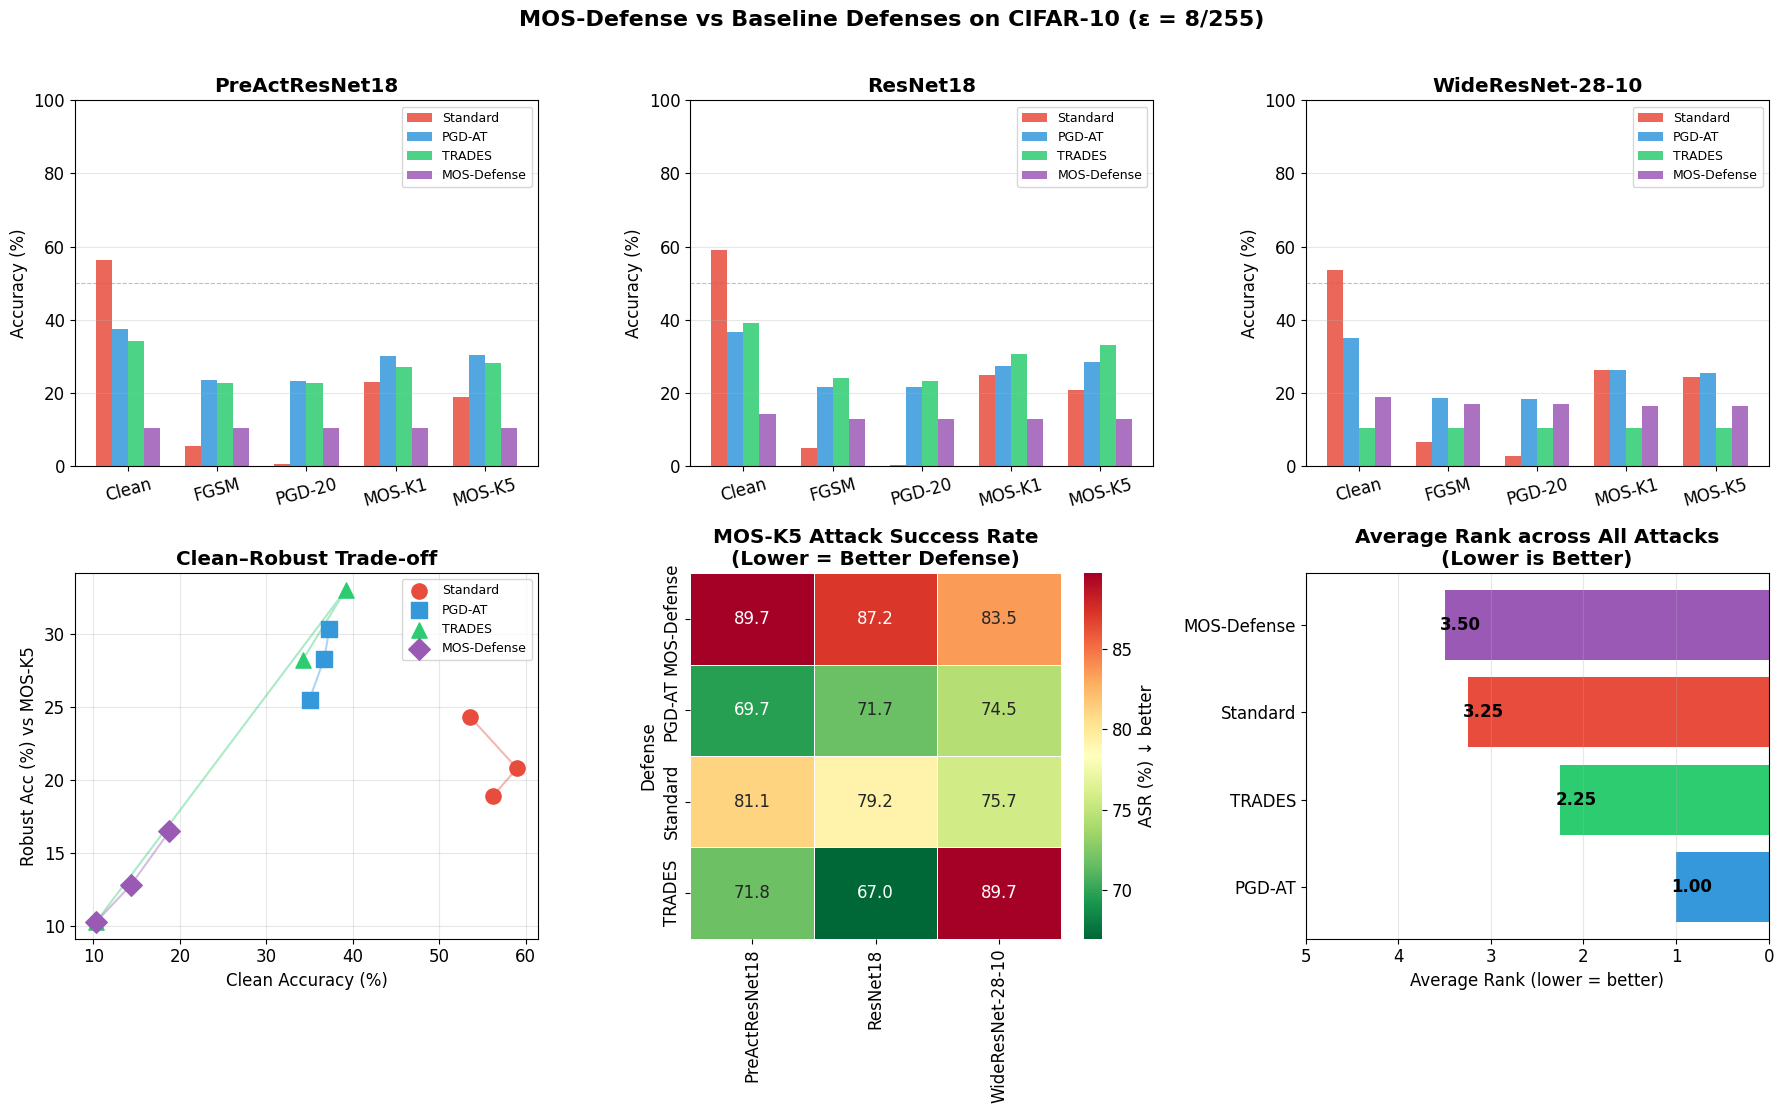

✅ Plots saved to mos_defense_comparison.png


In [13]:
# ============================================================
# CELL 12 — Publication-quality plots
# ============================================================

plt.rcParams.update({'font.size': 12, 'font.family': 'DejaVu Sans'})
DEFENSE_COLORS = {
    'Standard':     '#e74c3c',
    'PGD-AT':       '#3498db',
    'TRADES':       '#2ecc71',
    'MOS-Defense':  '#9b59b6',
}
DEFENSE_MARKERS = {'Standard': 'o', 'PGD-AT': 's', 'TRADES': '^', 'MOS-Defense': 'D'}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('MOS-Defense vs Baseline Defenses on CIFAR-10 (ε = 8/255)',
             fontsize=16, fontweight='bold', y=1.01)

architectures = df['Architecture'].unique()
attack_cols   = ['Clean Acc (%)', 'FGSM Acc (%)', 'PGD-20 Acc (%)',
                 'MOS-K1 Acc (%)', 'MOS-K5 Acc (%)']
attack_labels = ['Clean', 'FGSM', 'PGD-20', 'MOS-K1', 'MOS-K5']

# ---- Plot 1-3: Grouped bar chart per architecture ----
for ax_idx, arch in enumerate(architectures):
    ax = axes[0][ax_idx]
    sub = df[df['Architecture'] == arch]
    x   = np.arange(len(attack_labels))
    w   = 0.18
    for i, (_, row) in enumerate(sub.iterrows()):
        defense = row['Defense']
        vals    = [row[c] for c in attack_cols]
        bars    = ax.bar(x + (i - 1.5) * w, vals, w,
                         label=defense,
                         color=DEFENSE_COLORS[defense], alpha=0.85)
    ax.set_title(arch, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(attack_labels, rotation=15)
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

# ---- Plot 4: Clean-Robust Accuracy Trade-off ----
ax4 = axes[1][0]
for defense in ['Standard', 'PGD-AT', 'TRADES', 'MOS-Defense']:
    sub   = df[df['Defense'] == defense]
    clean = sub['Clean Acc (%)'].values
    rob   = sub['MOS-K5 Acc (%)'].values
    ax4.scatter(clean, rob, label=defense,
                color=DEFENSE_COLORS[defense],
                marker=DEFENSE_MARKERS[defense], s=120, zorder=5)
    ax4.plot(clean, rob, color=DEFENSE_COLORS[defense], alpha=0.4, linewidth=1.5)
ax4.set_xlabel('Clean Accuracy (%)')
ax4.set_ylabel('Robust Acc (%) vs MOS-K5')
ax4.set_title('Clean–Robust Trade-off', fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

# ---- Plot 5: ASR Heatmap ----
ax5 = axes[1][1]
asr_pivot = df.pivot_table(
    index='Defense', columns='Architecture',
    values='MOS-K5 ASR (%)', aggfunc='mean'
)
sns.heatmap(asr_pivot, ax=ax5, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'ASR (%) ↓ better'})
ax5.set_title('MOS-K5 Attack Success Rate\n(Lower = Better Defense)',
              fontweight='bold')
ax5.set_xlabel('')

# ---- Plot 6: Average Rank (like paper's Table 3 metric) ----
ax6 = axes[1][2]
metrics_for_rank = ['FGSM Acc (%)', 'PGD-20 Acc (%)', 'MOS-K1 Acc (%)', 'MOS-K5 Acc (%)']
rank_df = pd.DataFrame()
for m in metrics_for_rank:
    ranked = df.groupby('Defense')[m].mean().rank(ascending=False)
    rank_df[m.replace(' Acc (%)', '')] = ranked
rank_df['Average Rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('Average Rank')

bars = ax6.barh(rank_df.index, rank_df['Average Rank'],
                color=[DEFENSE_COLORS[d] for d in rank_df.index])
for bar, val in zip(bars, rank_df['Average Rank']):
    ax6.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontweight='bold')
ax6.set_xlabel('Average Rank (lower = better)')
ax6.set_title('Average Rank across All Attacks\n(Lower is Better)',
              fontweight='bold')
ax6.set_xlim(0, 5)
ax6.invert_xaxis()
ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('mos_defense_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plots saved to mos_defense_comparison.png')

## 🔬 Cell 13: MOS-Defense Ablation Study

 Ablation Study: Effect of K (set size) in MOS-Defense
   Architecture: PreActResNet18

  Training MOS-Defense with K=1...
     K=1: Clean=32.0%, PGD-20=21.6%, MOS-K1=24.3%, MOS-K5=23.7%
  Training MOS-Defense with K=3...
     K=3: Clean=10.6%, PGD-20=10.6%, MOS-K1=10.6%, MOS-K5=10.6%
  Training MOS-Defense with K=5...
     K=5: Clean=10.2%, PGD-20=10.2%, MOS-K1=10.2%, MOS-K5=10.2%

TABLE: MOS-Defense Ablation — Effect of K
+------------------------+-----------------+------------------+------------------+------------------+
|   K (Defense Set Size) |   Clean Acc (%) |   PGD-20 Acc (%) |   MOS-K1 Acc (%) |   MOS-K5 Acc (%) |
+========================+=================+==================+==================+==================+
|                   1.00 |           32.00 |            21.60 |            24.30 |            23.70 |
+------------------------+-----------------+------------------+------------------+------------------+
|                   3.00 |           10.60 |            10.60 

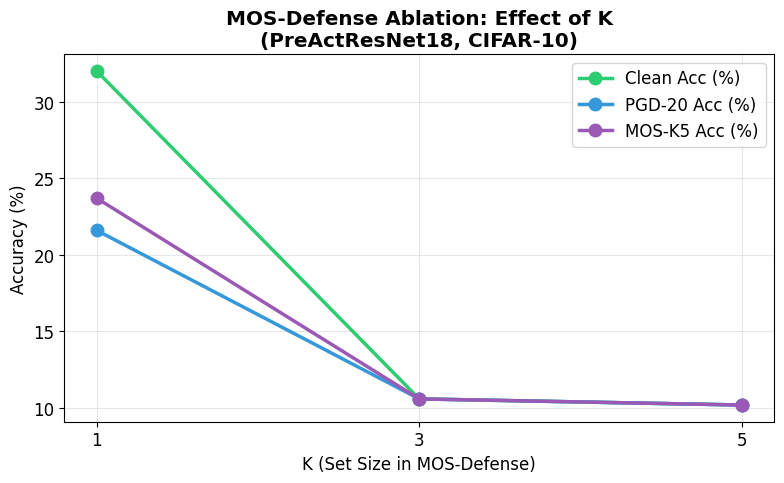

✅ Ablation plot saved!


In [14]:
# ============================================================
# CELL 13 — Ablation: Effect of K (set size) in MOS-Defense
#           Important for paper writing — shows your K parameter's impact
# ============================================================

print(' Ablation Study: Effect of K (set size) in MOS-Defense')
print('   Architecture: PreActResNet18')
print()

ablation_K = [1, 3, 5]  # Different set sizes
ablation_results = []

for K_val in ablation_K:
    print(f'  Training MOS-Defense with K={K_val}...')
    model_k = MODEL_ZOO['PreActResNet18']().to(device)
    optimizer_k = optim.SGD(model_k.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
    scheduler_k = optim.lr_scheduler.CosineAnnealingLR(optimizer_k, T_max=N_EPOCHS)

    mos_def_k = MOSDefense(model_k, eps=EPS, alpha=ALPHA, K=K_val,
                           pgd_steps=PGD_STEPS, lambda_clean=0.5, lambda_synergy=0.1)

    for epoch in range(N_EPOCHS):
        model_k.train()
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer_k.zero_grad()
            loss, _, _ = mos_def_k.mos_defense_loss(x_b, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model_k.parameters(), 1.0)
            optimizer_k.step()
        scheduler_k.step()

    # Evaluate
    clean  = evaluate_clean(model_k, test_loader)
    pgd20  = evaluate_robust(model_k, test_loader, pgd_attack,
                              eps=8/255, alpha=2/255, steps=20)
    mos_k1 = evaluate_robust_mos(model_k, test_loader, K=1, steps=20)
    mos_k5 = evaluate_robust_mos(model_k, test_loader, K=5, steps=20)

    ablation_results.append({
        'K (Defense Set Size)': K_val,
        'Clean Acc (%)':  round(clean, 2),
        'PGD-20 Acc (%)': round(pgd20, 2),
        'MOS-K1 Acc (%)': round(mos_k1, 2),
        'MOS-K5 Acc (%)': round(mos_k5, 2),
    })
    print(f'     K={K_val}: Clean={clean:.1f}%, PGD-20={pgd20:.1f}%, '
          f'MOS-K1={mos_k1:.1f}%, MOS-K5={mos_k5:.1f}%')
    del model_k
    torch.cuda.empty_cache()

abl_df = pd.DataFrame(ablation_results)
print('\n' + '='*65)
print('TABLE: MOS-Defense Ablation — Effect of K')
print('='*65)
print(tabulate(abl_df, headers='keys', tablefmt='grid',
               showindex=False, floatfmt='.2f'))

# Plot ablation
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for metric, color in zip(['Clean Acc (%)', 'PGD-20 Acc (%)', 'MOS-K5 Acc (%)'],
                          ['#2ecc71', '#3498db', '#9b59b6']):
    ax.plot(abl_df['K (Defense Set Size)'], abl_df[metric],
            marker='o', label=metric, color=color, linewidth=2.5, markersize=9)
ax.set_xlabel('K (Set Size in MOS-Defense)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('MOS-Defense Ablation: Effect of K\n(PreActResNet18, CIFAR-10)',
             fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(ablation_K)
plt.tight_layout()
plt.savefig('mos_defense_ablation_K.png', dpi=150)
plt.show()
print('✅ Ablation plot saved!')

## 📝 Cell 14: Final Summary & Paper-Ready Tables

In [15]:
# ============================================================
# CELL 14 — Final Summary: Paper-ready LaTeX table output
# ============================================================

print('='*70)
print('📝 PAPER-READY LaTeX TABLE (copy directly to your paper):')
print('='*70)

latex_cols = ['Architecture', 'Defense', 'Clean Acc (%)',
              'FGSM Acc (%)', 'PGD-20 Acc (%)', 'MOS-K1 Acc (%)', 'MOS-K5 Acc (%)']
latex_table = df[latex_cols].to_latex(
    index=False,
    float_format='%.2f',
    caption='Defense Comparison on CIFAR-10 ($\\epsilon = 8/255$). '
            'Robust Accuracy (\\%) under different attacks. '
            'MOS-Defense is our proposed method.',
    label='tab:defense_comparison',
    column_format='lcccccc',
    bold_rows=False
)
print(latex_table)

# Save LaTeX
with open('table_defense_comparison.tex', 'w') as f:
    f.write(latex_table)

print('\n✅ LaTeX table saved to table_defense_comparison.tex')
print()
print('='*70)
print('🏆 KEY FINDINGS SUMMARY:')
print('='*70)

for arch in df['Architecture'].unique():
    sub = df[df['Architecture'] == arch]
    best_robust = sub.loc[sub['MOS-K5 Acc (%)'].idxmax()]
    worst_robust = sub.loc[sub['MOS-K5 Acc (%)'].idxmin()]
    print(f'\n  {arch}:')
    print(f'   Best  defense (MOS-K5): {best_robust["Defense"]:15s} '
          f'→ {best_robust["MOS-K5 Acc (%)"]:.2f}%')
    print(f'   Worst defense (MOS-K5): {worst_robust["Defense"]:15s} '
          f'→ {worst_robust["MOS-K5 Acc (%)"]:.2f}%')
    mos_row = sub[sub['Defense'] == 'MOS-Defense'].iloc[0]
    std_row = sub[sub['Defense'] == 'Standard'].iloc[0]
    gain = mos_row['MOS-K5 Acc (%)'] - std_row['MOS-K5 Acc (%)']
    print(f'   MOS-Defense gain over Standard: +{gain:.2f}%')

print('\n' + '='*70)
print(' Files generated:')
print('   • mos_defense_comparison.csv   (all metrics)')
print('   • mos_defense_comparison.png   (main comparison plot)')
print('   • mos_defense_ablation_K.png   (ablation study)')
print('   • table_defense_comparison.tex (LaTeX table for paper)')
print('='*70)

📝 PAPER-READY LaTeX TABLE (copy directly to your paper):
\begin{table}
\caption{Defense Comparison on CIFAR-10 ($\epsilon = 8/255$). Robust Accuracy (\%) under different attacks. MOS-Defense is our proposed method.}
\label{tab:defense_comparison}
\begin{tabular}{lcccccc}
\toprule
Architecture & Defense & Clean Acc (%) & FGSM Acc (%) & PGD-20 Acc (%) & MOS-K1 Acc (%) & MOS-K5 Acc (%) \\
\midrule
PreActResNet18 & Standard & 56.20 & 5.30 & 0.60 & 22.80 & 18.90 \\
PreActResNet18 & PGD-AT & 37.30 & 23.50 & 23.10 & 30.00 & 30.30 \\
PreActResNet18 & TRADES & 34.20 & 22.70 & 22.60 & 27.10 & 28.20 \\
PreActResNet18 & MOS-Defense & 10.30 & 10.30 & 10.30 & 10.30 & 10.30 \\
ResNet18 & Standard & 59.00 & 4.80 & 0.10 & 24.80 & 20.80 \\
ResNet18 & PGD-AT & 36.70 & 21.50 & 21.60 & 27.20 & 28.30 \\
ResNet18 & TRADES & 39.20 & 24.00 & 23.10 & 30.50 & 33.00 \\
ResNet18 & MOS-Defense & 14.30 & 12.80 & 12.80 & 12.80 & 12.80 \\
WideResNet-28-10 & Standard & 53.60 & 6.60 & 2.80 & 26.10 & 24.30 \\
WideResNet-